In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
import numpy as np
import pandas as pd

# Friedman (1991): 10 predictors, only the first 5 are relevant
rng = np.random.default_rng(42)
n_samples = 2000
noise_std = 1.0

# X_j ~ Uniform(0, 1), j = 1, ..., 10
X_np = rng.uniform(0.0, 1.0, size=(n_samples, 10))
X = pd.DataFrame(X_np, columns=[f"x{i}" for i in range(1, 11)])

# y = 10 sin(pi x1 x2) + 20 (x3 - 0.5)^2 + 10 x4 + 5 x5 + eps
eps = rng.normal(0.0, noise_std, size=n_samples)
y = (
    10.0 * np.sin(np.pi * X["x1"] * X["x2"])
    + 20.0 * (X["x3"] - 0.5) ** 2
    + 10.0 * X["x4"]
    + 5.0 * X["x5"]
    + eps
)

In [3]:
X = X.values.astype(float)
y = np.array(y).reshape(-1)

In [4]:
notebook = "syn1_Friedman"

In [5]:
from experiment import run_parallel_experiments

# Run 5 parallel experiments
results = run_parallel_experiments(X, y, ndpost=10000, nskip=0, n_trees=100, notebook=notebook,
                                   n_runs=5, n_jobs=-2, store_preds=True,
                                   n_test_points=100, n_chains=4)

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   2 out of   5 | elapsed: 69.8min remaining: 104.7min
[Parallel(n_jobs=-2)]: Done   3 out of   5 | elapsed: 69.8min remaining: 46.5min
[Parallel(n_jobs=-2)]: Done   5 out of   5 | elapsed: 70.2min finished


In [6]:
import numpy as np
from pathlib import Path
import ast
import csv


def _load_numeric_csv(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        header = f.readline().strip()
    original_shape = ast.literal_eval(header.split('original_shape=', 1)[1])
    data = np.loadtxt(file_path, delimiter=',', skiprows=1)
    if np.isscalar(data):
        data = np.array([[data]])
    elif data.ndim == 1:
        data = data.reshape(1, -1)
    return data.reshape(original_shape)


def _load_metadata_csv(file_path):
    metadata = {}
    with open(file_path, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)
        for key, value in reader:
            try:
                metadata[key] = ast.literal_eval(value)
            except Exception:
                metadata[key] = value
    return metadata


def _load_metric(metric_name, model_name, n_runs, store_root, setting_tag):
    metric_runs = []
    for run_id in range(n_runs):
        file_path = store_root / metric_name / f'{setting_tag}__run{run_id:03d}__{model_name}__{metric_name}.csv'
        if file_path.exists():
            metric_runs.append(_load_numeric_csv(file_path))
    if metric_runs:
        return np.array(metric_runs)
    return np.array([])


store_root = Path('store')
setting_tag = notebook
metadata = _load_metadata_csv(store_root / 'metadata' / f'{setting_tag}__run000.csv')
n_runs = metadata['n_runs']

numeric_metrics = [
    'sigmas', 'rmses', 'leaves', 'depths', 'feature_ratios',
    'vector_distances', 'preds', 'coverage', 'subsample_X_test', 'subsample_y_test'
]

default_data = {}
mtmh_data = {}

for metric in numeric_metrics:
    default_metric = _load_metric(metric, 'default', n_runs, store_root, setting_tag)
    mtmh_metric = _load_metric(metric, 'mtmh', n_runs, store_root, setting_tag)
    if len(default_metric) > 0:
        default_data[metric] = default_metric
    if len(mtmh_metric) > 0:
        mtmh_data[metric] = mtmh_metric

experiment_results = {
    'default': np.array([default_data], dtype=object),
    'mtmh': np.array([mtmh_data], dtype=object),
    'metadata': np.array([metadata], dtype=object),
}

INFO:arviz.preview:arviz_base not installed
INFO:arviz.preview:arviz_stats not installed
INFO:arviz.preview:arviz_plots not installed


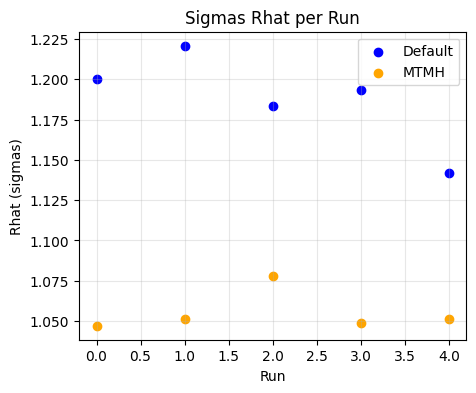

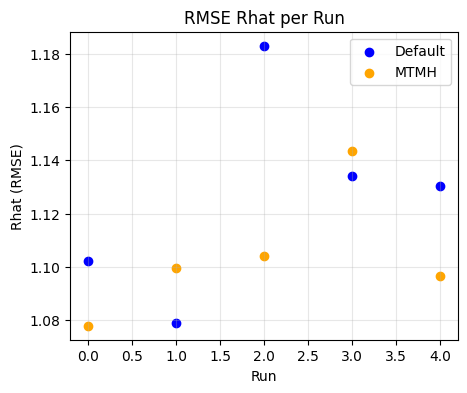

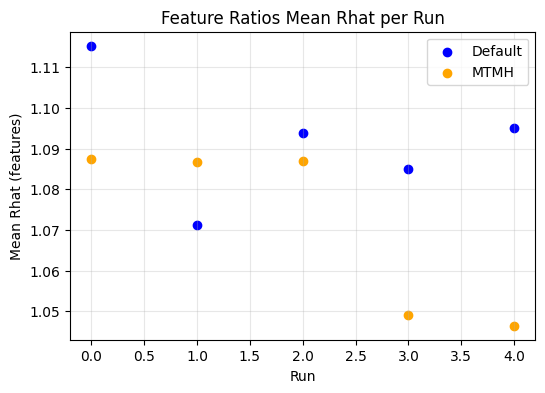

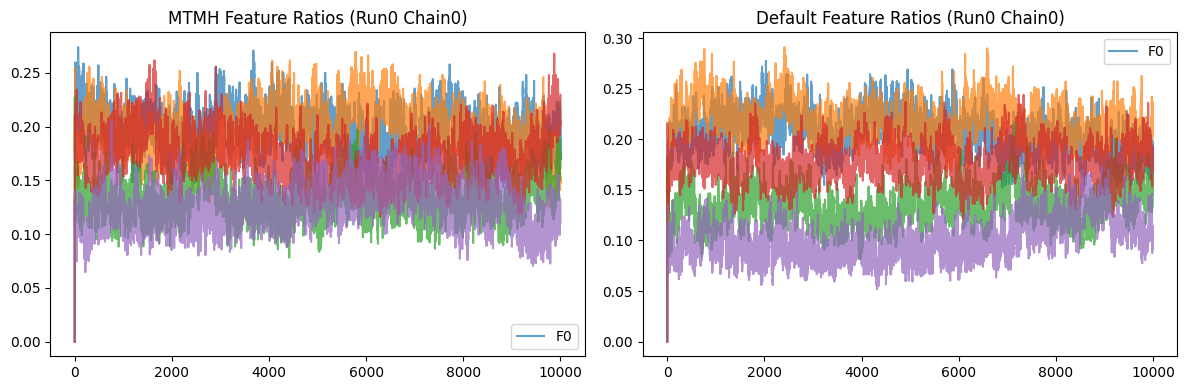

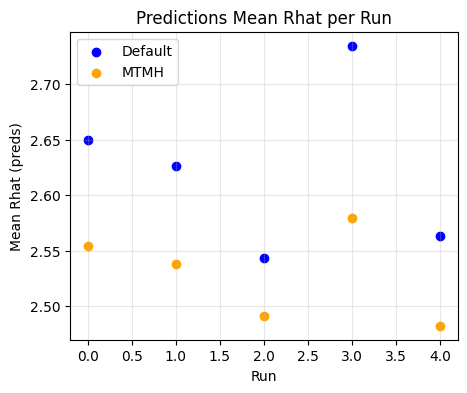

ESS (approx) — Default: 101.80653093782506 MTMH: 102.0307683328047


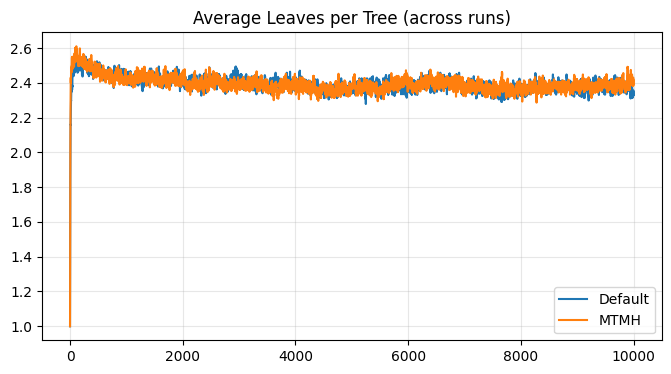

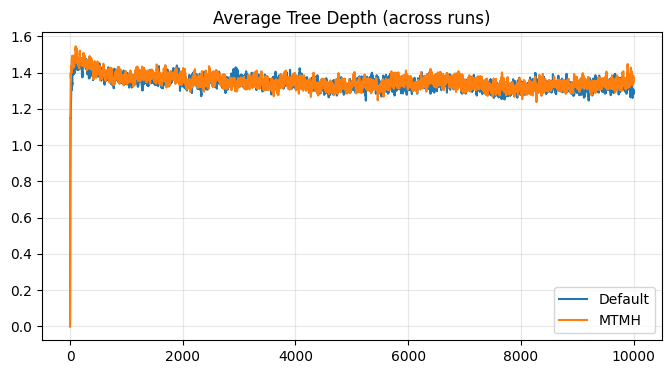

Friedman analysis cell completed.


In [7]:
# --- Analysis: Rhat, traces, ESS, leaves/depths, sigmas/rmse ---
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# Safety checks: ensure experiment_results is present and has metadata
if 'experiment_results' not in globals():
    print("No `experiment_results` found — run the experiment cell first.")
else:
    metadata = experiment_results['metadata'].item()
    n_runs = int(metadata.get('n_runs', 0))
    if n_runs == 0:
        print("No runs recorded in metadata; nothing to analyze.")
    else:
        default = experiment_results['default'].item()
        mtmh = experiment_results['mtmh'].item()

        # Helper: safe get
        def get_metric(dic, name):
            return dic.get(name, None)

        # --- Sigmas & RMSE Rhat per run (1D) ---
        def rhat_per_run_1d(arr):
            # arr expected shape: [n_runs, n_chains, n_iter]
            rhat = []
            for run_id in range(arr.shape[0]):
                chains = np.squeeze(arr[run_id])  # [n_chains, n_iter]
                rhat.append(az.rhat(chains))
            return np.array(rhat)

        sigmas_def = get_metric(default, 'sigmas')
        sigmas_mtmh = get_metric(mtmh, 'sigmas')
        rmses_def = get_metric(default, 'rmses')
        rmses_mtmh = get_metric(mtmh, 'rmses')

        if sigmas_def is None or sigmas_mtmh is None:
            print('Sigmas not found; skipping sigmas Rhat/plots.')
        else:
            default_sigmas_rhat = rhat_per_run_1d(sigmas_def[:, :, :])
            mtmh_sigmas_rhat = rhat_per_run_1d(sigmas_mtmh[:, :, :])

            plt.figure(figsize=(5,4))
            plt.scatter(np.arange(n_runs), default_sigmas_rhat, label='Default', color='blue')
            plt.scatter(np.arange(n_runs), mtmh_sigmas_rhat, label='MTMH', color='orange')
            plt.xlabel('Run')
            plt.ylabel('Rhat (sigmas)')
            plt.legend()
            plt.title('Sigmas Rhat per Run')
            plt.grid(alpha=0.3)
            plt.show()

        if rmses_def is None or rmses_mtmh is None:
            print('RMSEs not found; skipping RMSE Rhat/plots.')
        else:
            default_rmses_rhat = rhat_per_run_1d(rmses_def[:, :, :])
            mtmh_rmses_rhat = rhat_per_run_1d(rmses_mtmh[:, :, :])

            plt.figure(figsize=(5,4))
            plt.scatter(np.arange(n_runs), default_rmses_rhat, label='Default', color='blue')
            plt.scatter(np.arange(n_runs), mtmh_rmses_rhat, label='MTMH', color='orange')
            plt.xlabel('Run')
            plt.ylabel('Rhat (RMSE)')
            plt.legend()
            plt.title('RMSE Rhat per Run')
            plt.grid(alpha=0.3)
            plt.show()

        # --- Feature ratios trace & Rhat across features ---
        fr_def = get_metric(default, 'feature_ratios')
        fr_mtmh = get_metric(mtmh, 'feature_ratios')
        if fr_def is None or fr_mtmh is None:
            print('Feature ratios not found; skipping feature analysis.')
        else:
            # fr shape: [n_runs, n_chains, n_iter, n_features]
            n_runs_local, n_chains, n_iter, n_features = fr_def.shape

            def rhat_stats_per_run_ratios(ratios):
                mean_rhat = []
                rhat_list = []
                for run_id in range(ratios.shape[0]):
                    run_ratios = ratios[run_id]  # [n_chains, n_iter, n_features]
                    rhat_per_feat = []
                    for feat_id in range(n_features):
                        chains_feat = run_ratios[:, :, feat_id]
                        rhat = az.rhat(chains_feat)
                        rhat_per_feat.append(rhat)
                    mean_rhat.append(np.mean(rhat_per_feat))
                    rhat_list.append(rhat_per_feat)
                return np.array(mean_rhat), rhat_list

            def_plot_n = min(3, n_runs_local)
            default_mean_rhat, default_rhat_list = rhat_stats_per_run_ratios(fr_def)
            mtmh_mean_rhat, mtmh_rhat_list = rhat_stats_per_run_ratios(fr_mtmh)

            plt.figure(figsize=(6,4))
            plt.scatter(np.arange(n_runs_local), default_mean_rhat, label='Default', color='blue')
            plt.scatter(np.arange(n_runs_local), mtmh_mean_rhat, label='MTMH', color='orange')
            plt.xlabel('Run')
            plt.ylabel('Mean Rhat (features)')
            plt.title('Feature Ratios Mean Rhat per Run')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()

            # Trace plot for first run, chain 0
            run0_def = fr_def[0, 0, :, :]
            run0_mtmh = fr_mtmh[0, 0, :, :]
            fig, axes = plt.subplots(1,2, figsize=(12,4))
            for feat in range(min(5, n_features)):
                axes[0].plot(run0_mtmh[:, feat], label=f'F{feat}' if feat==0 else None, alpha=0.7)
                axes[1].plot(run0_def[:, feat], label=f'F{feat}' if feat==0 else None, alpha=0.7)
            axes[0].set_title('MTMH Feature Ratios (Run0 Chain0)')
            axes[1].set_title('Default Feature Ratios (Run0 Chain0)')
            axes[0].legend(); axes[1].legend()
            plt.tight_layout(); plt.show()

        # --- Predictions Rhat ---
        preds_def = get_metric(default, 'preds')
        preds_mtmh = get_metric(mtmh, 'preds')
        if preds_def is None or preds_mtmh is None:
            print('Predictions not found; skipping prediction Rhat/ESS.')
        else:
            # preds shape: [n_runs, n_chains, n_test_points, n_iter]
            n_test_points = preds_def.shape[2]

            def rhat_stats_per_run_preds(preds):
                mean_rhat = []
                rhat_list = []
                for run_id in range(preds.shape[0]):
                    run_preds = preds[run_id]
                    rhat_per_point = []
                    for pt_id in range(run_preds.shape[1]):
                        chains_pred = run_preds[:, pt_id, :]
                        rhat = az.rhat(chains_pred)
                        rhat_per_point.append(rhat)
                    mean_rhat.append(np.mean(rhat_per_point))
                    rhat_list.append(rhat_per_point)
                return np.array(mean_rhat), rhat_list

            default_mean_rhat_preds, _ = rhat_stats_per_run_preds(preds_def)
            mtmh_mean_rhat_preds, _ = rhat_stats_per_run_preds(preds_mtmh)

            plt.figure(figsize=(5,4))
            plt.scatter(np.arange(n_runs), default_mean_rhat_preds, label='Default', color='blue')
            plt.scatter(np.arange(n_runs), mtmh_mean_rhat_preds, label='MTMH', color='orange')
            plt.xlabel('Run')
            plt.ylabel('Mean Rhat (preds)')
            plt.title('Predictions Mean Rhat per Run')
            plt.legend(); plt.grid(alpha=0.3); plt.show()

            # ESS summary for first run
            ess_def = az.ess(preds_def[0].mean(axis=0)) if preds_def.size else None
            ess_mtmh = az.ess(preds_mtmh[0].mean(axis=0)) if preds_mtmh.size else None
            print('ESS (approx) — Default:', None if ess_def is None else float(ess_def),
                  'MTMH:', None if ess_mtmh is None else float(ess_mtmh))

        # --- Leaves / Depths analysis ---
        leaves_def = get_metric(default, 'leaves')
        leaves_mtmh = get_metric(mtmh, 'leaves')
        depths_def = get_metric(default, 'depths')
        depths_mtmh = get_metric(mtmh, 'depths')

        if leaves_def is not None and leaves_mtmh is not None:
            # leaves expected shape: [n_runs, 1, n_iter] or similar
            try:
                default_leaves_all = np.array([leaves_def[r][0] for r in range(n_runs)])
                mtmh_leaves_all = np.array([leaves_mtmh[r][0] for r in range(n_runs)])
                plt.figure(figsize=(8,4))
                plt.plot(default_leaves_all.mean(axis=0), label='Default')
                plt.plot(mtmh_leaves_all.mean(axis=0), label='MTMH')
                plt.title('Average Leaves per Tree (across runs)')
                plt.legend(); plt.grid(alpha=0.3); plt.show()
            except Exception:
                print('Leaves format unexpected; skipped leaves plot.')

        if depths_def is not None and depths_mtmh is not None:
            try:
                default_depths_all = np.array([depths_def[r][0] for r in range(n_runs)])
                mtmh_depths_all = np.array([depths_mtmh[r][0] for r in range(n_runs)])
                plt.figure(figsize=(8,4))
                plt.plot(default_depths_all.mean(axis=0), label='Default')
                plt.plot(mtmh_depths_all.mean(axis=0), label='MTMH')
                plt.title('Average Tree Depth (across runs)')
                plt.legend(); plt.grid(alpha=0.3); plt.show()
            except Exception:
                print('Depths format unexpected; skipped depths plot.')

        print('Friedman analysis cell completed.')